In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans ,DBSCAN ,AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Loading the data

In [27]:
df = pd.read_csv('data/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Data Exploration

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [29]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


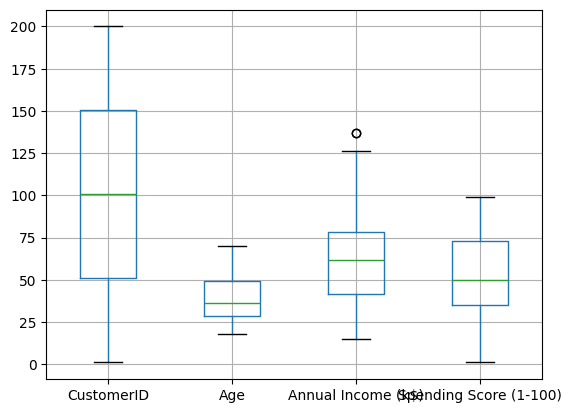

In [30]:
df.boxplot()
plt.show()

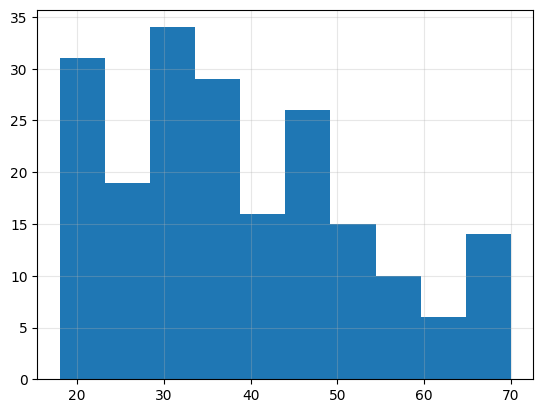

In [31]:
df['Age'].hist()
plt.grid(alpha=0.3)
plt.show()

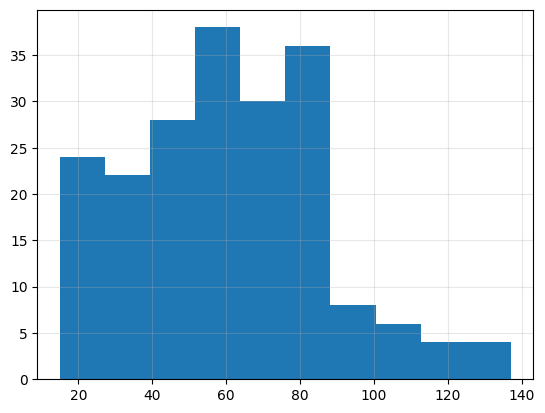

In [32]:
df['Annual Income (k$)'].hist()
plt.grid(alpha=0.3)
plt.show()

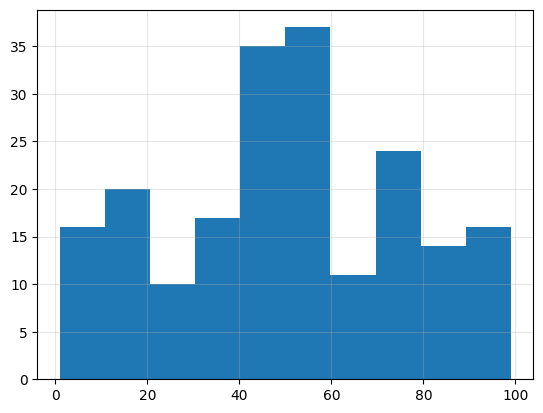

In [33]:
#Spending Score (1-100)
df['Spending Score (1-100)'].hist()
plt.grid(alpha=0.3)
plt.show()

In [34]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

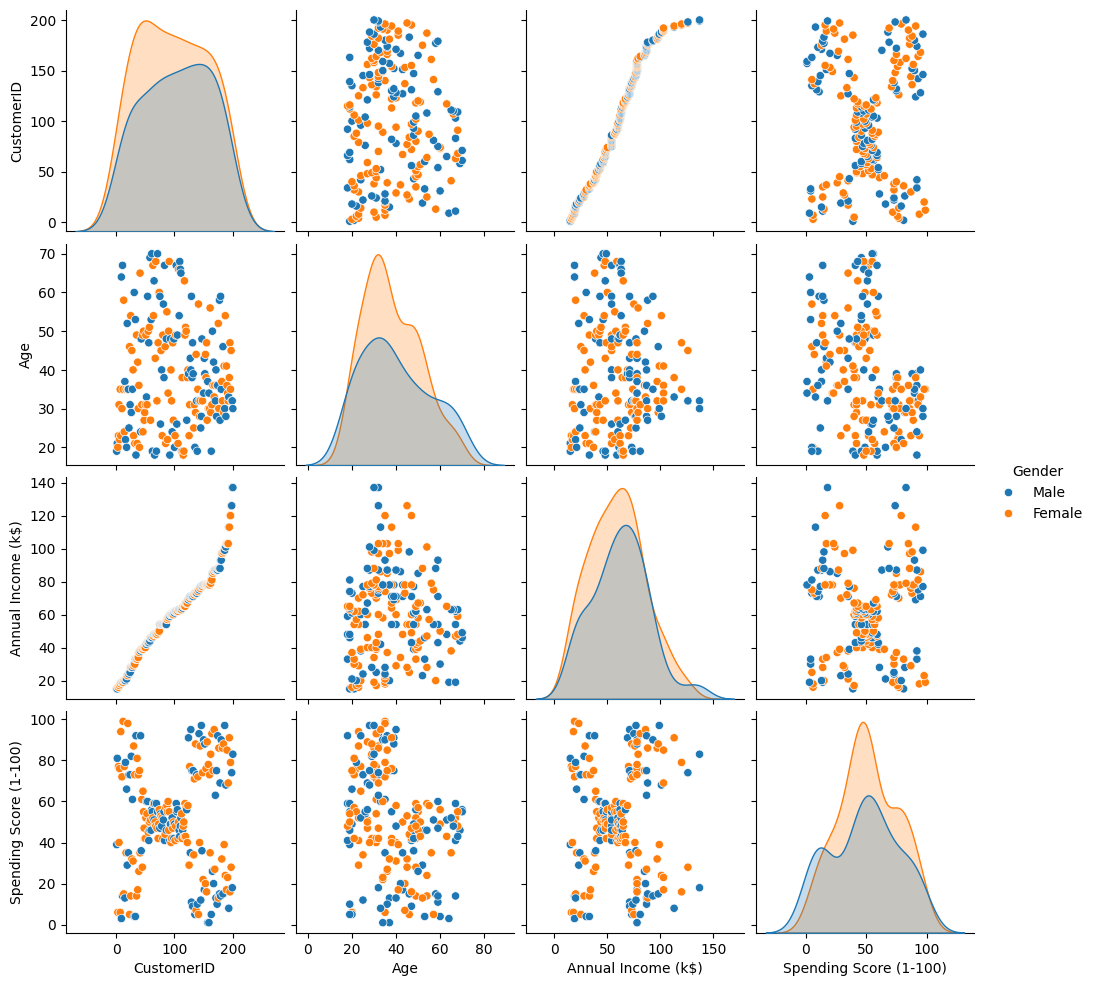

In [35]:
sns.pairplot(df, hue='Gender')
plt.show()

In [37]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Drop Unnecessary Columns

In [38]:
df.drop('CustomerID', axis=1, inplace=True)


## Label Encoding

In [39]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [41]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


In [43]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40
...,...,...,...,...
195,1,35,120,79
196,1,45,126,28
197,0,32,126,74
198,0,32,137,18


In [42]:
df_scaled

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [ 0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [ 0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [ 0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [-1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [ 0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [-1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [ 0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [ 0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [ 0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [-1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [-1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [ 0.88640526, -0.

# KMeans

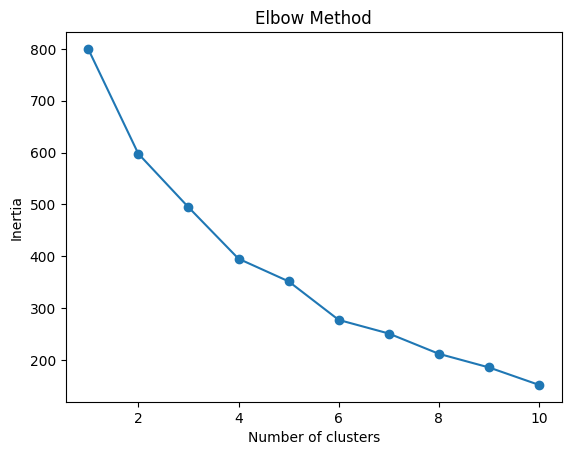

In [81]:
# Find optimal K using Elbow Method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()



In [82]:


silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

#1: Points are well matched to their own cluster and far from others (great).

#0: Points are on or very close to the decision boundary.

#Negative: Points might be in the wrong cluster

k=2, Silhouette Score=0.2776
k=3, Silhouette Score=0.2576
k=4, Silhouette Score=0.2901
k=5, Silhouette Score=0.2719
k=6, Silhouette Score=0.3348
k=7, Silhouette Score=0.3457
k=8, Silhouette Score=0.3728
k=9, Silhouette Score=0.3876
k=10, Silhouette Score=0.4208


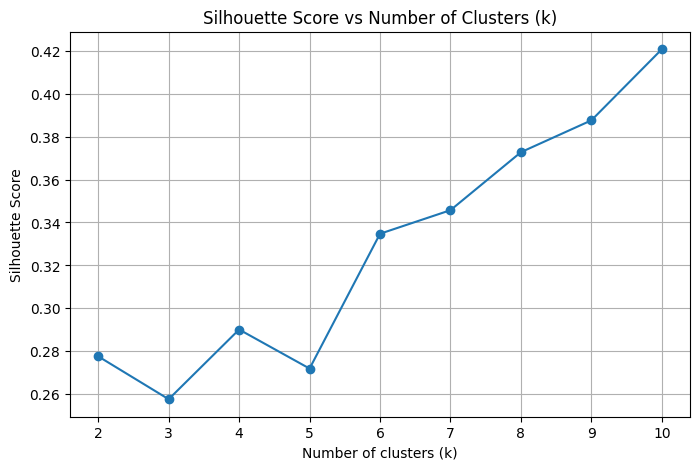

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters (k)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [85]:

kmeans = KMeans(n_clusters=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

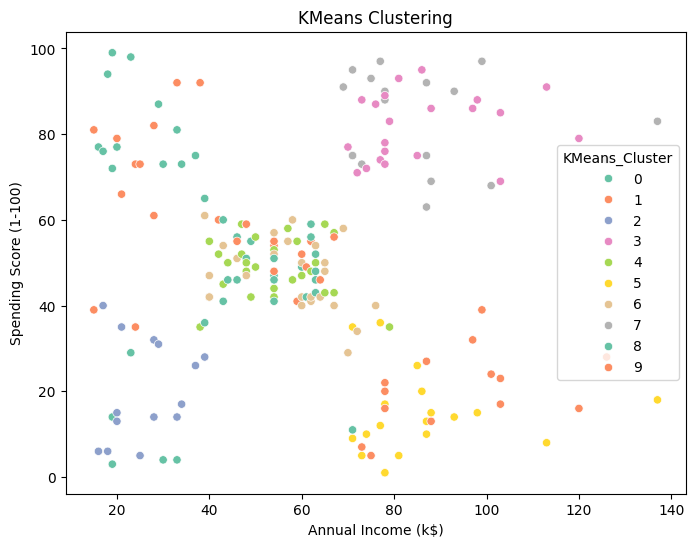

In [86]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='Set2'
)
plt.title('KMeans Clustering')
plt.show()

# DBSCAN

In [103]:

db = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = db.fit_predict(df_scaled)


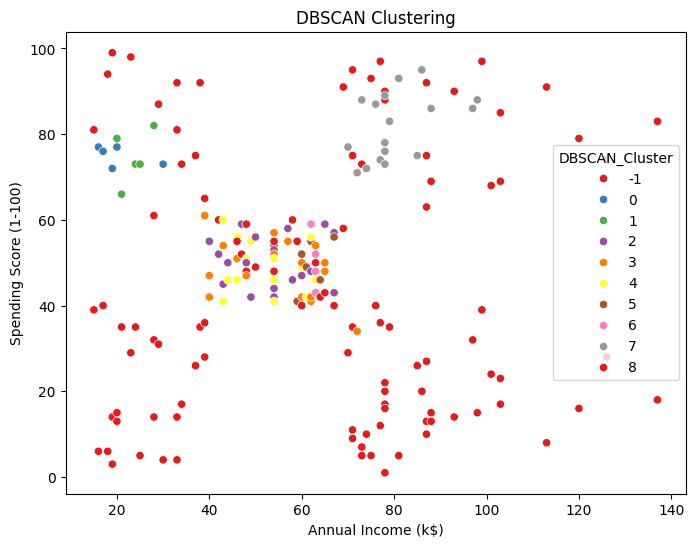

In [104]:
# DBSCAN already added the labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    palette='Set1'
)
plt.title('DBSCAN Clustering')
plt.show()


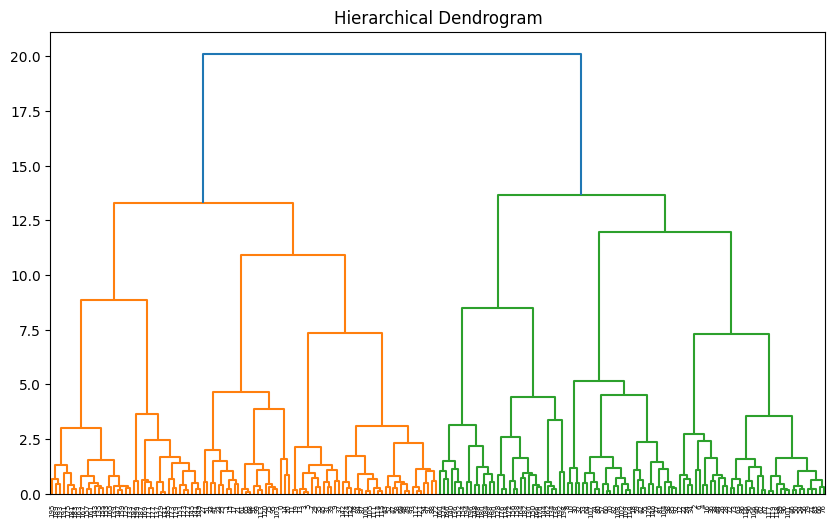

In [55]:

linked = linkage(df_scaled, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title('Hierarchical Dendrogram')
plt.show()

hc = AgglomerativeClustering(n_clusters=5)
df['Hierarchical_Cluster'] = hc.fit_predict(df_scaled)


#  if we take only ['Annual Income (k$)','Spending Score (1-100)']

In [106]:
df2=df[['Annual Income (k$)','Spending Score (1-100)']]

In [107]:
df2

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [111]:
scaler = StandardScaler()
df2_scaled = scaler.fit_transform(df2)

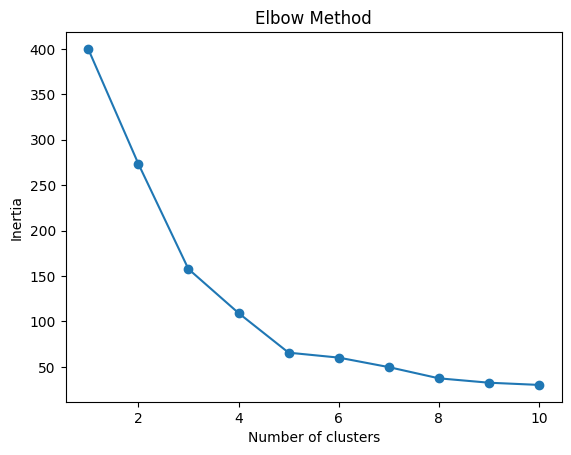

In [112]:
# Find optimal K using Elbow Method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df2_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [113]:
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df2_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.3973
k=3, Silhouette Score=0.4666
k=4, Silhouette Score=0.4943
k=5, Silhouette Score=0.5547
k=6, Silhouette Score=0.5138
k=7, Silhouette Score=0.5020
k=8, Silhouette Score=0.4550
k=9, Silhouette Score=0.4567
k=10, Silhouette Score=0.4448


In [123]:

kmeans = KMeans(n_clusters=5, random_state=42)
df['KMCluster'] = kmeans.fit_predict(df2_scaled)

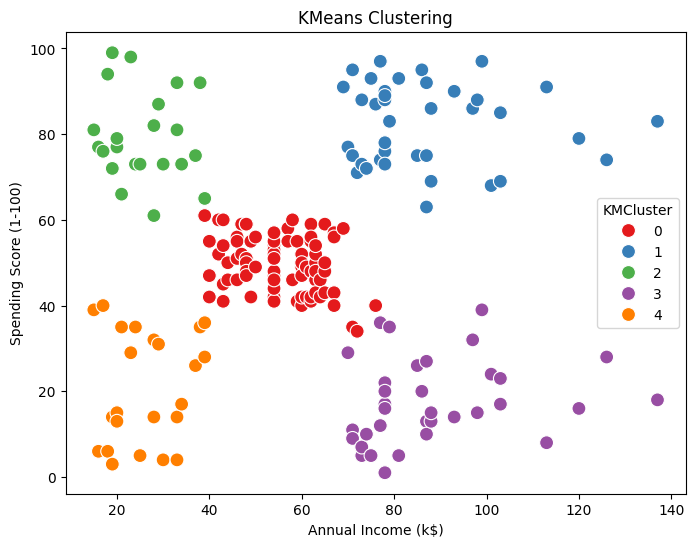

In [124]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMCluster',
    data=df,
    palette='Set1',
    s=100
)
plt.title('KMeans Clustering')
plt.show()